# Big Ten Basketball: Do Travel Distance and Rest Explain Performance Against Expectation?

**Author:** Michael McGuire  
**Data:** Big Ten men's basketball schedules (2024–25 and 2025–26 seasons), Sports Reference; team efficiency ratings, KenPom


This report is an analysis on the effect of travel distance and rest days on the performance of big ten basketball teams for the 2024-25 and 2025-26 seasons.
The dataset was created using sportsrefrence.com's big ten schedule. I then used kenpom's net rating system to create a point spread for each game. I did this by taking each teams net rating the day of the game. The net rating system for Kenpom is an adjusted efficiency margin between the team's offensive and defensive ratings. These ratings are per 100 possessions, and the average number of possessions in a game is 70, so I multiplied the difference in the ratings by 0.70 to get the point spread. I created the point spread to get an expectation for the game which would give us a better representation of the outcome. From the point spread I could create the cover score which is the difference between the game score and the point spread. A positive game score meant the home team out preformed expectations and the opposite is true for a negative cover score.

## 1. Data Preparation

Build the game-level dataset and derive the core performance metric used throughout this analysis: **cover score**, the difference between a team's actual result and its expected result.

In [17]:
import pandas as pd

schedule = pd.read_csv("Data/big_ten_results.csv")
schedule = schedule.rename(columns={"PTS" : "AWAY SCORE",
                                    "PTS.1" : "HOME SCORE",
                                    "Visitor/Neutral" : "AWAY TEAM",
                                    "Home/Neutral" : "HOME TEAM",
                                    "Date" : "DATE"})

schedule["DATE"] = pd.to_datetime(schedule["DATE"], format="%a, %b %d, %Y", errors="coerce")
schedule["COMBINED RATINGS"] = schedule["HOME RATING"] - schedule["AWAY RATING"]
schedule["POINT SPREAD"] = schedule["COMBINED RATINGS"] * 0.70
schedule["GAME SCORE"] = schedule["HOME SCORE"] - schedule["AWAY SCORE"]
schedule["COVER SCORE"] = schedule["GAME SCORE"] - schedule["POINT SPREAD"]

## 2. Travel Distance vs. Performance


I used the geodesic package to be able to compare distance traveled to cover score. I used the coordinates of the cities the schools are located in and used the coordinates to calculate the distance traveled of the away team.

In [18]:
from geopy.distance import geodesic

team_locations = {
    "Iowa": (41.6637, -91.5542),
    "Michigan State": (42.7281, -84.4927),
    "Oregon": (44.0451, -123.0669),
    "Rutgers": (40.5255, -74.4408),
    "Minnesota": (44.9730, -93.2277),
    "Washington": (47.6502, -122.3016),
    "Wisconsin": (43.0695, -89.4125),
    "Michigan": (42.2808, -83.7430),
    "Northwestern": (42.0565, -87.6753),
    "Purdue": (40.4237, -86.9212),
    "Indiana": (39.1653, -86.5264),
    "UCLA": (34.0689, -118.4452),
    "Southern California": (34.0211, -118.2851),
    "Maryland": (38.9869, -76.9426),
    "Ohio State": (40.0067, -83.0305),
    "Penn State": (40.8075, -77.8568),
    "Nebraska": (40.8136, -96.7026),
    "Illinois": (40.1020, -88.2272),
}

def get_travel_distance(row):
    away_team = row["AWAY TEAM"]
    home_team = row["HOME TEAM"]

    away_location = team_locations.get(away_team)
    home_location = team_locations.get(home_team)

    if away_location is None or home_location is None:
        return None

    return geodesic(away_location, home_location).miles

schedule["AWAY TRAVEL MILES"] = schedule.apply(get_travel_distance, axis=1)

This is the graph I got when I compared the Travel Distance to the cover score. There appears to be no linear relationship between the two variables.

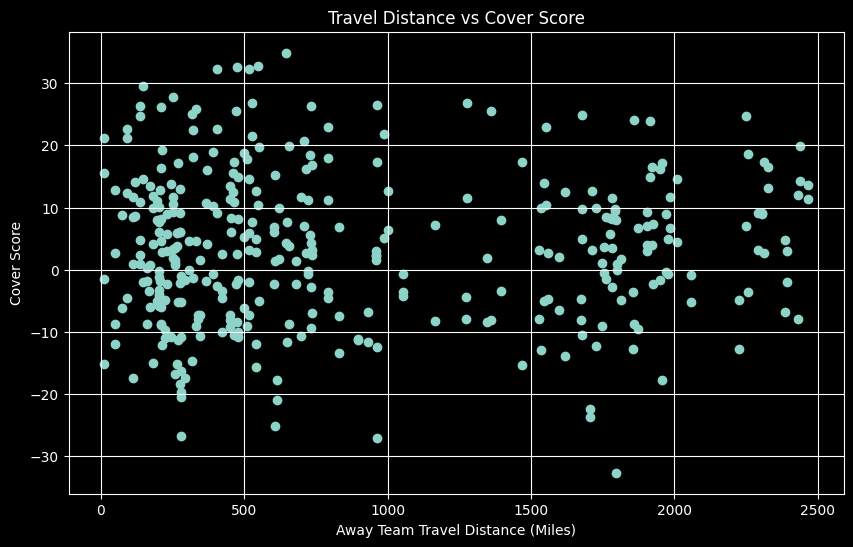

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    schedule["AWAY TRAVEL MILES"],
    schedule["COVER SCORE"]
)

plt.xlabel("Away Team Travel Distance (Miles)")
plt.ylabel("Cover Score")
plt.title("Travel Distance vs Cover Score")

plt.grid(True)

plt.show()

In [20]:
from scipy.stats import pearsonr

x = schedule["AWAY TRAVEL MILES"]
y = schedule["COVER SCORE"]

corr, p_value = pearsonr(x, y)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.024097918483262374
P-value: 0.6486043504137506


**Interpretation:** the correlation between travel distance and cover score is essentially zero (r = 0.024, p = 0.65). Travel distance alone does not explain how a team performs relative to expectation.

For context, here's how each team's cover score has added up over the sample as a home team (not a causal result — just descriptive):

In [21]:
schedule.groupby("HOME TEAM")["COVER SCORE"].sum().sort_values(ascending=False)

HOME TEAM
Michigan State         181.326
UCLA                   175.610
Wisconsin              139.106
Rutgers                114.250
Maryland               112.378
Indiana                104.624
Nebraska                80.816
Purdue                  68.201
Minnesota               67.065
Iowa                    53.420
Ohio State              47.010
Penn State              26.121
Illinois                21.862
Oregon                  18.925
Northwestern             9.798
Southern California      7.798
Michigan                 4.787
Washington               1.396
Name: COVER SCORE, dtype: float64

## 3. Rest Days vs. Performance

Next, engineer a *days-of-rest* feature for every team ahead of each game, for both the home and away side.

In [22]:
import numpy as np

home = schedule[["DATE", "HOME TEAM"]].rename(columns={"HOME TEAM": "TEAM"})
away = schedule[["DATE", "AWAY TEAM"]].rename(columns={"AWAY TEAM": "TEAM"})

team_schedule = pd.concat([home, away], ignore_index=True)

team_schedule["DATE"] = pd.to_datetime(team_schedule["DATE"])

team_schedule = team_schedule.sort_values(["TEAM", "DATE"])

team_schedule["REST DAYS"] = (
    team_schedule.groupby("TEAM")["DATE"]
    .diff()
    .dt.days)

team_schedule.loc[
    team_schedule["REST DAYS"] >= 9,
    "REST DAYS"
] = np.nan

home_rest = team_schedule.rename(columns={
    "TEAM": "HOME TEAM",
    "REST DAYS": "HOME REST DAYS"
})

schedule = schedule.merge(
    home_rest[["DATE", "HOME TEAM", "HOME REST DAYS"]],
    on=["DATE", "HOME TEAM"],
    how="left"
)

away_rest = team_schedule.rename(columns={
    "TEAM": "AWAY TEAM",
    "REST DAYS": "AWAY REST DAYS"
})

schedule = schedule.merge(
    away_rest[["DATE", "AWAY TEAM", "AWAY REST DAYS"]],
    on=["DATE", "AWAY TEAM"],
    how="left"
)


schedule.loc[194, ["HOME REST DAYS", "AWAY REST DAYS"]] = np.nan

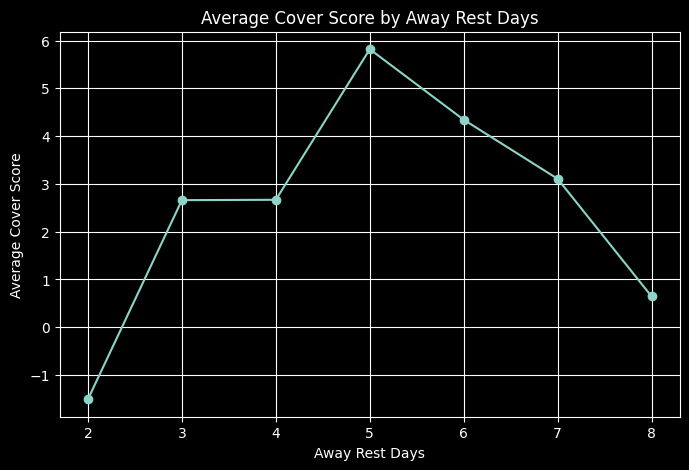

In [23]:
rest_avg = (
    schedule.groupby("AWAY REST DAYS")["COVER SCORE"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(rest_avg.index, rest_avg.values, marker="o")

plt.xlabel("Away Rest Days")
plt.ylabel("Average Cover Score")
plt.title("Average Cover Score by Away Rest Days")

plt.grid(True)
plt.show()

In [24]:
from scipy.stats import f_oneway

groups = [
    group["COVER SCORE"].dropna()
    for _, group in schedule.groupby("AWAY REST DAYS")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.4692460068287954
p-value: 0.830985261645746


**Interpretation:** a one-way ANOVA across away-team rest-day groups shows no significant difference in average cover score (F = 0.47, p = 0.83) — teams with 2 days of rest don't perform meaningfully differently than teams with 7.

In [25]:
schedule.groupby("AWAY REST DAYS")["COVER SCORE"].agg(
    ["count", "mean", "std"]
)

,count,mean,std
AWAY REST DAYS,,,
2.0,2,-1.507000,15.182997
3.0,177,2.659605,11.252245
4.0,82,2.667171,12.565511
5.0,38,5.818447,12.620983
6.0,10,4.342600,11.476301
7.0,9,3.105556,16.034754
8.0,2,0.644000,5.658268


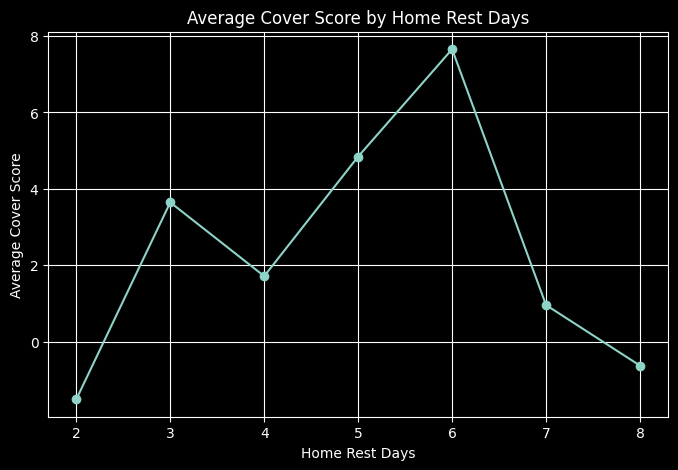

In [26]:
rest_avg = (
    schedule.groupby("HOME REST DAYS")["COVER SCORE"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(rest_avg.index, rest_avg.values, marker="o")

plt.xlabel("Home Rest Days")
plt.ylabel("Average Cover Score")
plt.title("Average Cover Score by Home Rest Days")

plt.grid(True)
plt.show()

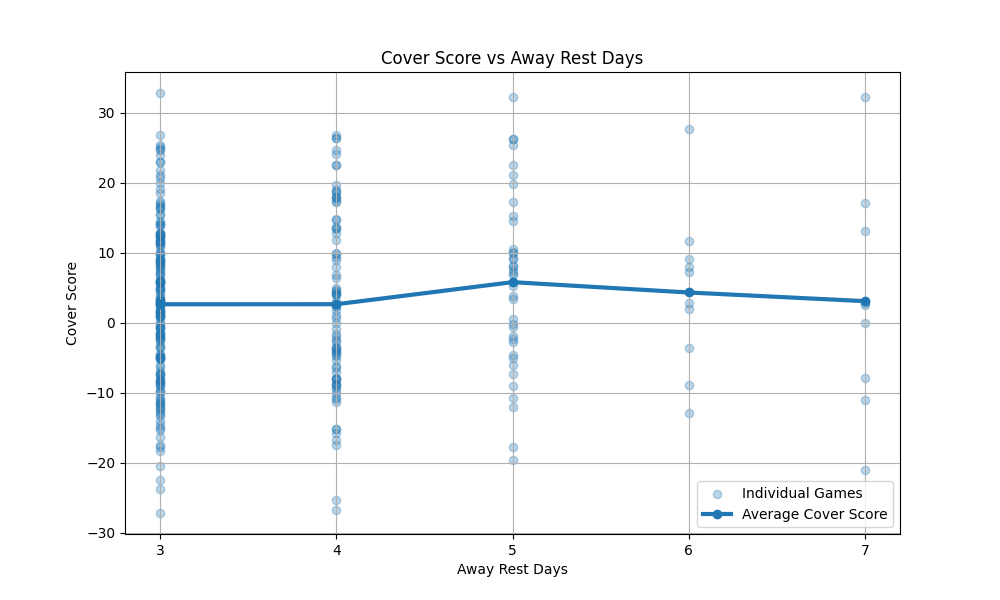

In [27]:
from matplotlib.ticker import MaxNLocator
away_rest_data = schedule[
    schedule["AWAY REST DAYS"].between(3, 7)
]

avg_cover = away_rest_data.groupby("AWAY REST DAYS")["COVER SCORE"].mean()

plt.figure(figsize=(10, 6))

plt.scatter(
    away_rest_data["AWAY REST DAYS"],
    away_rest_data["COVER SCORE"],
    alpha=0.3,
    label="Individual Games"
)

plt.plot(
    avg_cover.index,
    avg_cover.values,
    marker="o",
    linewidth=3,
    label="Average Cover Score"
)

plt.xlabel("Away Rest Days")
plt.ylabel("Cover Score")
plt.title("Cover Score vs Home Rest Days")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True)

plt.show()

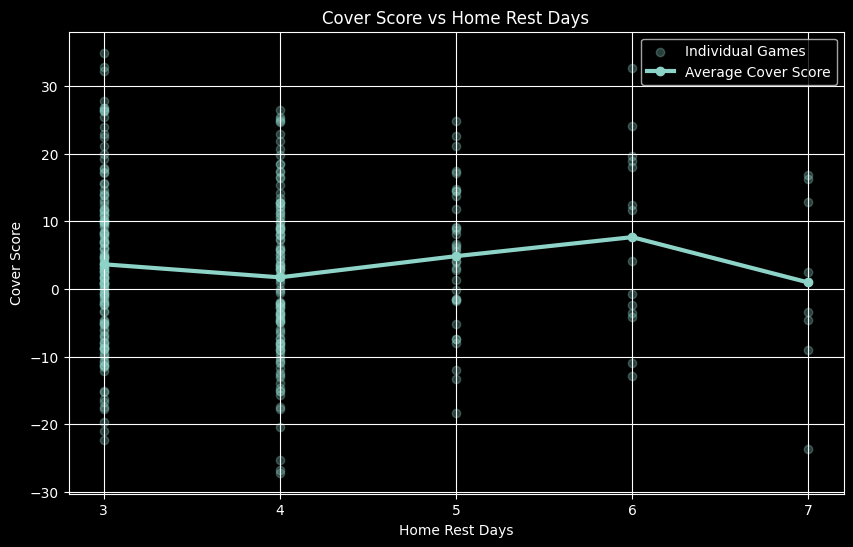

In [28]:
home_rest_data = schedule[
    schedule["HOME REST DAYS"].between(3, 7)
]

avg_cover = home_rest_data.groupby("HOME REST DAYS")["COVER SCORE"].mean()

plt.figure(figsize=(10, 6))

plt.scatter(
    home_rest_data["HOME REST DAYS"],
    home_rest_data["COVER SCORE"],
    alpha=0.3,
    label="Individual Games"
)

plt.plot(
    avg_cover.index,
    avg_cover.values,
    marker="o",
    linewidth=3,
    label="Average Cover Score"
)

plt.xlabel("Home Rest Days")
plt.ylabel("Cover Score")
plt.title("Cover Score vs Home Rest Days")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True)

plt.show()

## 4. Combining Travel and Rest

Does a team's performance change when *both* long travel and short rest happen together?

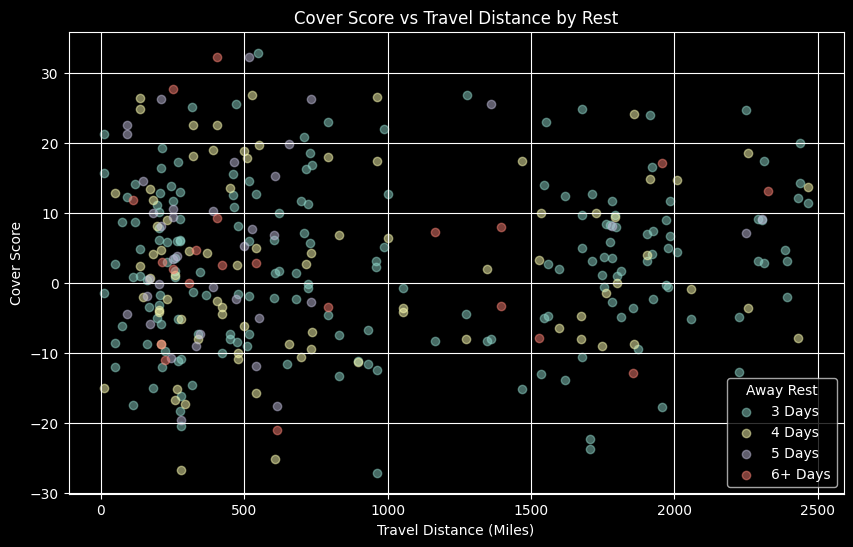

In [29]:
schedule["REST GROUP"] = schedule["AWAY REST DAYS"].apply(
    lambda x: "3 Days" if x == 3
    else "4 Days" if x == 4
    else "5 Days" if x == 5
    else "6+ Days" if x >= 6
    else None
)

plot_data = schedule.dropna(subset=[
    "REST GROUP",
    "AWAY TRAVEL MILES",
    "COVER SCORE"
])

plt.figure(figsize=(10, 6))

for rest_group in ["3 Days", "4 Days", "5 Days", "6+ Days"]:

    data = plot_data[plot_data["REST GROUP"] == rest_group]

    plt.scatter(
        data["AWAY TRAVEL MILES"],
        data["COVER SCORE"],
        alpha=0.5,
        label=rest_group
    )

plt.xlabel("Travel Distance (Miles)")
plt.ylabel("Cover Score")
plt.title("Cover Score vs Travel Distance by Rest")
plt.legend(title="Away Rest")
plt.grid(True)

plt.show()

## 5. Regression Modeling

Finally, test travel distance and rest days together (and their interaction) as joint predictors of cover score using OLS regression.

In [30]:
import statsmodels.formula.api as smf

model1 = smf.ols(
    "Q('COVER SCORE') ~ Q('AWAY REST DAYS') + Q('AWAY TRAVEL MILES')",
    data=schedule
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:       Q('COVER SCORE')   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9551
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.386
Time:                        16:26:11   Log-Likelihood:                -1244.0
No. Observations:                 320   AIC:                             2494.
Df Residuals:                     317   BIC:                             2505.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

Adding an interaction term between rest days and travel distance:

In [31]:
model2 = smf.ols(
    "Q('COVER SCORE') ~ Q('AWAY REST DAYS') * Q('AWAY TRAVEL MILES')",
    data=schedule
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       Q('COVER SCORE')   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.6408
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.589
Time:                        16:26:11   Log-Likelihood:                -1244.0
No. Observations:                 320   AIC:                             2496.
Df Residuals:                     316   BIC:                             2511.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Testing a quadratic (non-linear) rest-days effect, in case the relationship isn't a straight line:

In [32]:
model_quad = smf.ols(
    "Q('COVER SCORE') ~ Q('AWAY REST DAYS') + "
    "I(Q('AWAY REST DAYS')**2) + "
    "Q('AWAY TRAVEL MILES')",
    data= schedule
).fit()

print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:       Q('COVER SCORE')   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9321
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.425
Time:                        16:26:11   Log-Likelihood:                -1243.6
No. Observations:                 320   AIC:                             2495.
Df Residuals:                     316   BIC:                             2510.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Conclusion

Across every method used — Pearson correlation, one-way ANOVA, and three OLS regression specifications (linear, interaction, and quadratic) — **neither travel distance nor rest days showed a statistically significant relationship with performance against expectation** (all p-values > 0.05; the best-fitting model explained under 1% of the variance in cover score, R² = 0.009).

**Takeaways:**
- Big Ten teams' performance against a KenPom-based point spread does not appear to be meaningfully affected by how far they traveled or how many days of rest they had before the game.
- This is a genuine null result, not a modeling failure: it was tested with a linear model, an interaction term, and a quadratic term, and all three agree.
- One plausible explanation is that the point spread (from KenPom ratings) may already implicitly price in typical travel and scheduling effects, or that conference scheduling in the Big Ten doesn't create enough variation in travel/rest to produce a detectable effect.

**Next steps I'd explore with more time:** a larger sample across multiple conferences and seasons, controlling for injuries and back-to-back games specifically, and testing whether time-zone changes (rather than raw mileage) affect West Coast opponents differently.